# Analise simples de vendedores com nota baixa

Objetivo:
- Filtrar vendedores com media de review menor que 3
- Manter apenas vendedores com 5 ou mais vendas totais
- Avaliar frete, prazo de entrega e categorias com mais problemas

Regras deste notebook:
- Carregar tabelas da pasta data
- Fazer limpeza em blocos separados
- Gerar um grafico por bloco

In [53]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)

In [54]:
# 1) Carregamento das tabelas da pasta data
data_dir = Path("data")

reviews = pd.read_csv(data_dir / "olist_order_reviews_dataset.csv")
order_items = pd.read_csv(data_dir / "olist_order_items_dataset.csv")
orders = pd.read_csv(data_dir / "olist_orders_dataset.csv")
sellers = pd.read_csv(data_dir / "olist_sellers_dataset.csv")
products = pd.read_csv(data_dir / "olist_products_dataset.csv")

print("reviews:", reviews.shape)
print("order_items:", order_items.shape)
print("orders:", orders.shape)
print("sellers:", sellers.shape)
print("products:", products.shape)

reviews: (99224, 7)
order_items: (112650, 7)
orders: (99441, 8)
sellers: (3095, 4)
products: (32951, 9)


In [55]:
# 2) Limpeza da tabela reviews
# Outlier aqui eh tratado por regra de negocio: review_score valido entre 1 e 5.
reviews_before = len(reviews)

reviews_clean = reviews.copy()
reviews_clean = reviews_clean.drop_duplicates(subset=["review_id"])
reviews_clean = reviews_clean[reviews_clean["review_score"].between(1, 5)]
reviews_clean["review_comment_title"] = reviews_clean["review_comment_title"].fillna("")
reviews_clean["review_comment_message"] = reviews_clean["review_comment_message"].fillna("")

print(f"reviews antes: {reviews_before}")
print(f"reviews depois: {len(reviews_clean)}")

reviews antes: 99224
reviews depois: 98410


In [56]:
# 3) Limpeza da tabela order_items
# Remove duplicados e outliers de price/freight_value via IQR.
items_before = len(order_items)

order_items_clean = order_items.copy().drop_duplicates()
order_items_clean["price"] = pd.to_numeric(order_items_clean["price"], errors="coerce")
order_items_clean["freight_value"] = pd.to_numeric(order_items_clean["freight_value"], errors="coerce")
order_items_clean = order_items_clean.dropna(subset=["price", "freight_value"])
order_items_clean = order_items_clean[(order_items_clean["price"] >= 0) & (order_items_clean["freight_value"] >= 0)]

q1_price = order_items_clean["price"].quantile(0.25)
q3_price = order_items_clean["price"].quantile(0.75)
iqr_price = q3_price - q1_price
lim_inf_price = max(0, q1_price - 1.5 * iqr_price)
lim_sup_price = q3_price + 1.5 * iqr_price

q1_freight = order_items_clean["freight_value"].quantile(0.25)
q3_freight = order_items_clean["freight_value"].quantile(0.75)
iqr_freight = q3_freight - q1_freight
lim_inf_freight = max(0, q1_freight - 1.5 * iqr_freight)
lim_sup_freight = q3_freight + 1.5 * iqr_freight

mask_items = (
    order_items_clean["price"].between(lim_inf_price, lim_sup_price)
    & order_items_clean["freight_value"].between(lim_inf_freight, lim_sup_freight)
)
order_items_clean = order_items_clean[mask_items].copy()

print(f"order_items antes: {items_before}")
print(f"order_items depois: {len(order_items_clean)}")
print(f"Faixa price usada: {lim_inf_price:.2f} ate {lim_sup_price:.2f}")
print(f"Faixa freight usada: {lim_inf_freight:.2f} ate {lim_sup_freight:.2f}")

order_items antes: 112650
order_items depois: 95092
Faixa price usada: 0.00 ate 277.40
Faixa freight usada: 0.98 ate 33.25


In [57]:
# 4) Limpeza da tabela orders
# Converte datas, cria prazos e remove outliers de prazo via IQR.
orders_before = len(orders)

orders_clean = orders.copy().drop_duplicates(subset=["order_id"])

date_cols = [
    "order_purchase_timestamp",
    "order_estimated_delivery_date",
    "order_delivered_customer_date",
]
for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors="coerce")

orders_clean = orders_clean[orders_clean["order_status"] != "canceled"]
orders_clean = orders_clean.dropna(subset=["order_purchase_timestamp", "order_estimated_delivery_date", "order_delivered_customer_date"])

orders_clean["prazo_estimado_dias"] = (
    orders_clean["order_estimated_delivery_date"] - orders_clean["order_purchase_timestamp"]
).dt.days
orders_clean["prazo_real_dias"] = (
    orders_clean["order_delivered_customer_date"] - orders_clean["order_purchase_timestamp"]
).dt.days
orders_clean["atraso_dias"] = (
    orders_clean["order_delivered_customer_date"] - orders_clean["order_estimated_delivery_date"]
).dt.days

orders_clean = orders_clean[(orders_clean["prazo_estimado_dias"] >= 0) & (orders_clean["prazo_real_dias"] >= 0)]

q1_est = orders_clean["prazo_estimado_dias"].quantile(0.25)
q3_est = orders_clean["prazo_estimado_dias"].quantile(0.75)
iqr_est = q3_est - q1_est
lim_inf_est = max(0, q1_est - 1.5 * iqr_est)
lim_sup_est = q3_est + 1.5 * iqr_est

q1_real = orders_clean["prazo_real_dias"].quantile(0.25)
q3_real = orders_clean["prazo_real_dias"].quantile(0.75)
iqr_real = q3_real - q1_real
lim_inf_real = max(0, q1_real - 1.5 * iqr_real)
lim_sup_real = q3_real + 1.5 * iqr_real

mask_orders = (
    orders_clean["prazo_estimado_dias"].between(lim_inf_est, lim_sup_est)
    & orders_clean["prazo_real_dias"].between(lim_inf_real, lim_sup_real)
)
orders_clean = orders_clean[mask_orders].copy()

print(f"orders antes: {orders_before}")
print(f"orders depois: {len(orders_clean)}")
print(f"Faixa prazo estimado: {lim_inf_est:.2f} ate {lim_sup_est:.2f}")
print(f"Faixa prazo real: {lim_inf_real:.2f} ate {lim_sup_real:.2f}")

orders antes: 99441
orders depois: 89509
Faixa prazo estimado: 3.00 ate 43.00
Faixa prazo real: 0.00 ate 28.50


In [58]:
# 5) Limpeza da tabela sellers
# Esta tabela nao possui metrica numerica forte para IQR.
# Aqui fazemos limpeza estrutural para manter qualidade da chave seller_id e UF.
sellers_before = len(sellers)

sellers_clean = sellers.copy().drop_duplicates(subset=["seller_id"])
sellers_clean["seller_state"] = sellers_clean["seller_state"].astype(str).str.upper().str.strip()
sellers_clean["seller_city"] = sellers_clean["seller_city"].astype(str).str.lower().str.strip()
sellers_clean = sellers_clean[sellers_clean["seller_state"].str.len() == 2]

print(f"sellers antes: {sellers_before}")
print(f"sellers depois: {len(sellers_clean)}")

sellers antes: 3095
sellers depois: 3095


In [59]:
# 6) Limpeza da tabela products
# Remove outliers de peso e dimensoes via IQR.
products_before = len(products)

products_clean = products.copy().drop_duplicates(subset=["product_id"])
products_clean["product_category_name"] = products_clean["product_category_name"].fillna("sem_categoria")

num_cols = ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]
for col in num_cols:
    products_clean[col] = pd.to_numeric(products_clean[col], errors="coerce")
    products_clean.loc[products_clean[col] <= 0, col] = pd.NA

for col in num_cols:
    serie = products_clean[col].dropna()
    if len(serie) == 0:
        continue
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = max(0, q1 - 1.5 * iqr)
    lim_sup = q3 + 1.5 * iqr
    mask_col = products_clean[col].isna() | products_clean[col].between(lim_inf, lim_sup)
    products_clean = products_clean[mask_col].copy()

print(f"products antes: {products_before}")
print(f"products depois: {len(products_clean)}")

products antes: 32951
products depois: 25591


In [ ]:
# 7) Montagem da base analitica
# Junta as tabelas limpas e cria recorte principal: media_review < 3 e qtd_vendas_totais >= 5.
base = order_items_clean[["order_id", "seller_id", "product_id", "freight_value"]].merge(
    reviews_clean[["order_id", "review_score", "review_comment_title", "review_comment_message"]],
    on="order_id",
    how="inner",
)

base = base.merge(
    orders_clean[["order_id", "prazo_estimado_dias", "prazo_real_dias", "atraso_dias"]],
    on="order_id",
    how="inner",
)

base = base.merge(
    sellers_clean[["seller_id", "seller_state", "seller_city"]],
    on="seller_id",
    how="left",
)

base = base.merge(
    products_clean[["product_id", "product_category_name"]],
    on="product_id",
    how="left",
)

mapa_regiao = {
    "AC": "Norte", "AP": "Norte", "AM": "Norte", "PA": "Norte", "RO": "Norte", "RR": "Norte", "TO": "Norte",
    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste", "MA": "Nordeste", "PB": "Nordeste", "PE": "Nordeste", "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",
    "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MT": "Centro-Oeste", "MS": "Centro-Oeste",
    "ES": "Sudeste", "MG": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
    "PR": "Sul", "RS": "Sul", "SC": "Sul",
}
base["regiao"] = base["seller_state"].map(mapa_regiao).fillna("Nao identificado")

seller_stats = base.groupby("seller_id", as_index=False).agg(
    media_review=("review_score", "mean"),
    qtd_vendas_avaliadas=("order_id", "nunique"),
    frete_medio=("freight_value", "mean"),
    atraso_medio=("atraso_dias", "mean"),
)
seller_stats["media_review"] = seller_stats["media_review"].round(2)

# Quantidade total de vendas por seller (nao depende de review).
vendas_totais_seller = (
    order_items_clean[["order_id", "seller_id"]]
    .drop_duplicates()
    .merge(
        orders[["order_id", "order_status"]].drop_duplicates(subset=["order_id"]),
        on="order_id",
        how="left",
    )
)
vendas_totais_seller = vendas_totais_seller[vendas_totais_seller["order_status"] != "canceled"]
vendas_totais_seller = (
    vendas_totais_seller.groupby("seller_id", as_index=False)["order_id"]
    .nunique()
    .rename(columns={"order_id": "qtd_vendas_totais"})
)

# Adiciona regiao e vendas totais no resumo do seller.
seller_regiao = base[["seller_id", "regiao"]].drop_duplicates(subset=["seller_id"])
seller_stats = seller_stats.merge(seller_regiao, on="seller_id", how="left")
seller_stats = seller_stats.merge(vendas_totais_seller, on="seller_id", how="left")
seller_stats["qtd_vendas_totais"] = seller_stats["qtd_vendas_totais"].fillna(0).astype(int)

# Base de comparacao: apenas sellers com volume minimo relevante.
seller_stats_analise = seller_stats[seller_stats["qtd_vendas_totais"] >= 5].copy()
seller_stats_analise["grupo"] = seller_stats_analise["media_review"].apply(
    lambda x: "Problema (review < 3)" if x < 3 else "Controle (review >= 3)"
)

# Recorte principal (grupo problema) para tabelas e comentarios.
recorte = seller_stats_analise[seller_stats_analise["grupo"] == "Problema (review < 3)"].copy()

# Base por pedido ja com grupo para analises comparativas.
base_com_grupo = base.merge(
    seller_stats_analise[["seller_id", "grupo", "media_review", "qtd_vendas_totais"]],
    on="seller_id",
    how="inner",
)
base_com_grupo["entrega_atrasada"] = (base_com_grupo["atraso_dias"] > 0).astype(int)

base_recorte = base_com_grupo[base_com_grupo["grupo"] == "Problema (review < 3)"].copy()

categorias_recorte = (
    base_recorte["product_category_name"].fillna("sem_categoria")
    .value_counts()
    .head(10)
    .rename_axis("categoria")
    .reset_index(name="qtd_itens")
)

comentarios_recorte = base_recorte[(
    (base_recorte["review_comment_title"].str.strip() != "")
    | (base_recorte["review_comment_message"].str.strip() != "")
)][["seller_id", "review_score", "review_comment_title", "review_comment_message"]].drop_duplicates()

print(f"Sellers na analise (>= 5 vendas totais): {len(seller_stats_analise)}")
print(f"Vendedores no recorte problema (review < 3): {len(recorte)}")
print("Distribuicao por grupo:")
display(seller_stats_analise["grupo"].value_counts().rename("qtd_sellers").to_frame())

print(f"Comentarios encontrados no recorte: {len(comentarios_recorte)}")
display(
    recorte[["seller_id", "media_review", "qtd_vendas_totais", "qtd_vendas_avaliadas", "frete_medio", "atraso_medio", "regiao"]]
    .sort_values(["media_review", "qtd_vendas_totais"], ascending=[True, False])
    .head(10)
)

Vendedores no recorte (media < 3 e >= 5 vendas totais): 25


,seller_id,media_review,qtd_vendas_totais,qtd_vendas_avaliadas,frete_medio,atraso_medio,regiao
688,4342d4b2ba6b161468c63a7e7cfce593,1.00,19,1,23.410000,6.000000,Sudeste
2032,c6a7539d424a8402232c2228d7a03c5e,2.10,7,6,20.321000,-10.900000,Sudeste
1686,a36ac007a4d18f865c8d32c3b2402c2d,2.20,7,5,16.610000,-22.600000,Sudeste
827,5151aea44289d6c6b090ee31c2132508,2.25,7,4,20.710000,-26.500000,Sudeste
1868,b7ed9fb14c8eadb37adb9c45d67ab0fb,2.25,5,5,14.308750,-14.625000,Sudeste
394,270d3ef21830ad0ecf3a6c53d08a533a,2.29,6,5,12.800588,-9.058824,Sudeste
276,1ca7077d890b907f89be8c954a02686a,2.33,115,98,11.690085,-7.837607,Sudeste
959,5bc55dbe2f12b6af6d83ed46023e0dc8,2.44,16,14,18.892778,-13.611111,Sudeste
2304,e250d617a0ad591ba9bd663e584a895d,2.61,7,6,14.220556,-14.500000,Sudeste
393,2709af9587499e95e803a6498a5a56e9,2.62,25,21,10.992381,-4.761905,Sudeste


Comentarios encontrados no recorte: 241


,seller_id,review_score,review_comment_title,review_comment_message
710,5bc55dbe2f12b6af6d83ed46023e0dc8,2,,"Péssimo e gosto horrível! Impossível de beber , não desolve! Me sinto arrependida! lannister usei só 1scop gostaria ..."
814,2eb70248d66e0e3ef83659f71b244378,3,produto é uma replica,em nenhum momento do anuncio o vendedor expôs que o produto era uma replica de primeira linha
989,2eb70248d66e0e3ef83659f71b244378,1,Já solicitei a devolução,Produto enviado é falaificado
1267,2eb70248d66e0e3ef83659f71b244378,1,pessimo,produto com defeito.
1303,2eb70248d66e0e3ef83659f71b244378,2,Nenhuma,Não recebi nada ainda!!;
1794,1ca7077d890b907f89be8c954a02686a,1,,os produtos entregues não são os funko pops originais. são claramente uma cópia. quero meu dinheiro de volta e a dev...
2103,1ca7077d890b907f89be8c954a02686a,2,,"Na imagem o produto parecia maior, a qualidade e péssima, ja tem arranhões, e não gostei em, nada!\r\nestou devolvendo."
3176,a36ac007a4d18f865c8d32c3b2402c2d,3,,"No site a mercadoria vinha junto estojo, mas este não veio."
3279,25debeafbce801fdd479539350185eee,1,não recebi o pedido todo,ja enviei mensagem e ate hoje não me responderam . so recebi parte do pedido
3282,2eb70248d66e0e3ef83659f71b244378,1,Relógio falso,"Relógio falso, me admiro com uma loja grande como as lannister permitir terceiros a vender produtos falsos"


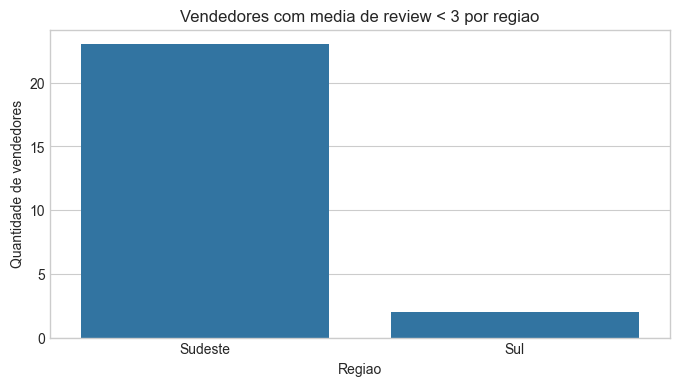

In [ ]:
# 8) Grafico 1 - Taxa de atraso por grupo
# Pergunta: vendedores com nota baixa atrasam mais as entregas?
if base_com_grupo.empty:
    print("Sem dados para plotar.")
else:
    taxa_atraso = base_com_grupo.groupby("grupo", as_index=False)["entrega_atrasada"].mean()
    taxa_atraso["taxa_atraso_pct"] = taxa_atraso["entrega_atrasada"] * 100

    plt.figure(figsize=(8, 4))
    ax = sns.barplot(data=taxa_atraso, x="grupo", y="taxa_atraso_pct", color="#1f77b4")
    plt.title("Taxa de pedidos com atraso por grupo")
    plt.xlabel("Grupo")
    plt.ylabel("Taxa de atraso (%)")

    for idx, row in taxa_atraso.reset_index(drop=True).iterrows():
        ax.text(idx, row["taxa_atraso_pct"] + 0.5, f"{row['taxa_atraso_pct']:.1f}%", ha="center")

    plt.show()

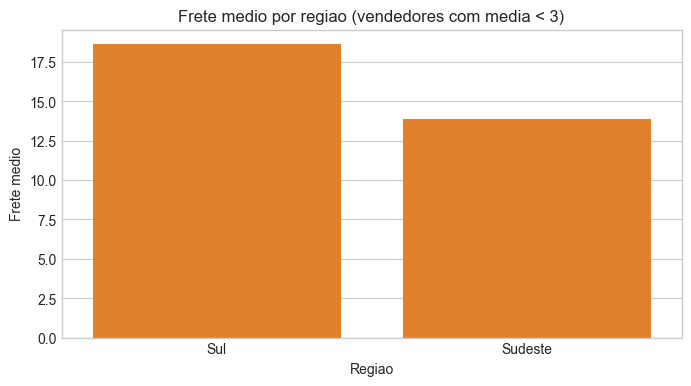

In [ ]:
# 9) Grafico 2 - Distribuicao do frete por grupo
# Pergunta: o grupo com nota baixa pratica/gera fretes maiores?
if base_com_grupo.empty:
    print("Sem dados para plotar.")
else:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=base_com_grupo, x="grupo", y="freight_value", showfliers=False)
    plt.title("Distribuicao do frete por grupo (sem outliers visuais)")
    plt.xlabel("Grupo")
    plt.ylabel("Frete (R$)")
    plt.show()

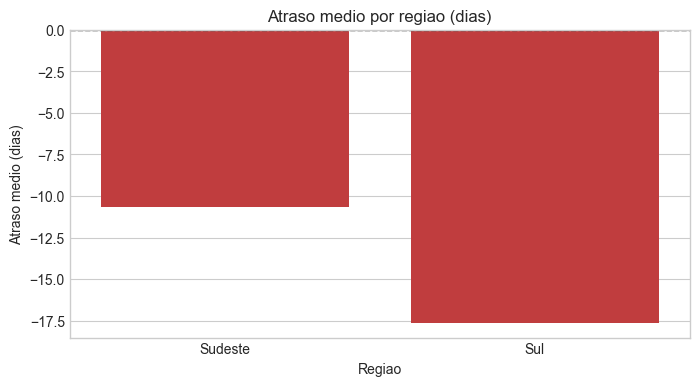

In [ ]:
# 10) Grafico 3 - Relacao entre atraso medio e media de review (seller)
# Pergunta: maior atraso medio tende a piorar a nota media do seller?
if seller_stats_analise.empty:
    print("Sem dados para plotar.")
else:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=seller_stats_analise,
        x="atraso_medio",
        y="media_review",
        hue="grupo",
        size="qtd_vendas_totais",
        sizes=(40, 260),
        alpha=0.75,
    )
    sns.regplot(
        data=seller_stats_analise,
        x="atraso_medio",
        y="media_review",
        scatter=False,
        color="black",
        line_kws={"linestyle": "--", "linewidth": 1},
    )
    plt.axhline(3, color="gray", linestyle=":", linewidth=1)
    plt.axvline(0, color="gray", linestyle=":", linewidth=1)
    plt.title("Atraso medio x media de review por seller")
    plt.xlabel("Atraso medio (dias)")
    plt.ylabel("Media de review")
    plt.show()

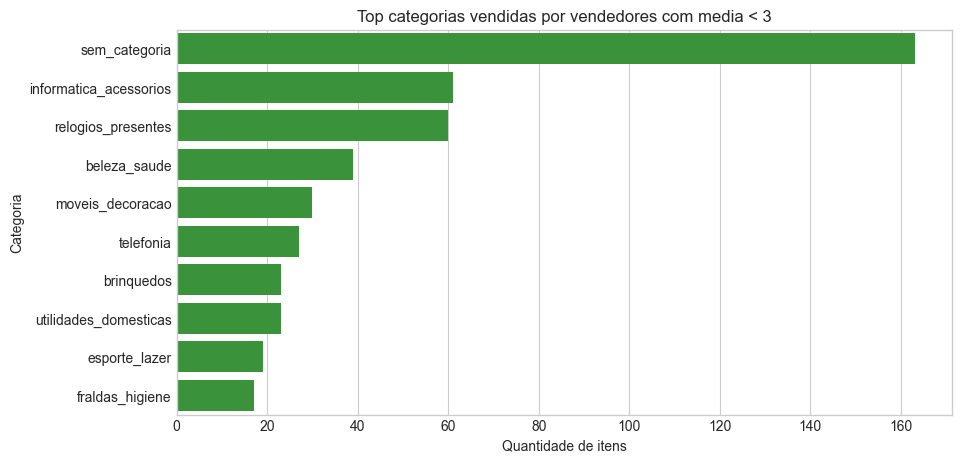

In [ ]:
# 11) Grafico 4 - Categorias com maior concentracao de sellers do grupo problema
# Pergunta: quais categorias concentram mais ocorrencias do grupo de nota baixa?
if base_com_grupo.empty:
    print("Sem dados para plotar.")
else:
    cat_plot = base_com_grupo.copy()
    cat_plot["problema"] = (cat_plot["grupo"] == "Problema (review < 3)").astype(int)
    cat_plot["categoria"] = cat_plot["product_category_name"].fillna("sem_categoria")

    cat_plot = (
        cat_plot.groupby("categoria", as_index=False)
        .agg(
            qtd_itens=("order_id", "count"),
            taxa_problema=("problema", "mean"),
            media_review_cat=("review_score", "mean"),
        )
    )

    # Mantem categorias com volume minimo para evitar leitura distorcida.
    cat_plot = cat_plot[cat_plot["qtd_itens"] >= 30].copy()
    cat_plot["taxa_problema_pct"] = cat_plot["taxa_problema"] * 100
    cat_plot = cat_plot.sort_values("taxa_problema_pct", ascending=False).head(10)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=cat_plot, y="categoria", x="taxa_problema_pct", color="#2ca02c")
    plt.title("Top categorias por taxa de ocorrencia do grupo problema")
    plt.xlabel("Taxa de ocorrencia do grupo problema (%)")
    plt.ylabel("Categoria")
    plt.show()

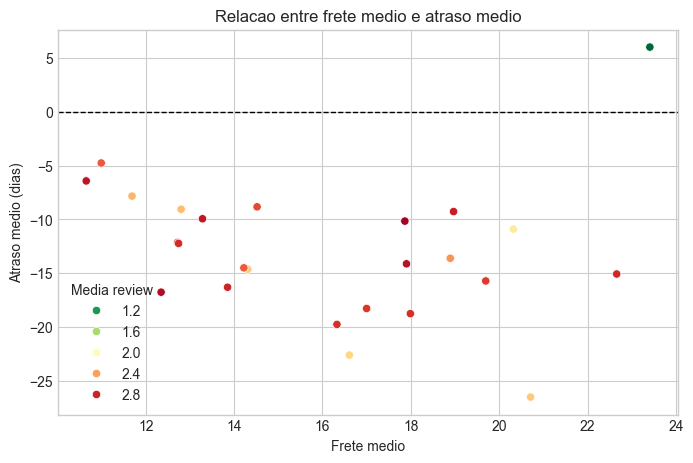

In [ ]:
# 12) Grafico 5 - Temas mais recorrentes nos comentarios do grupo problema
# Pergunta: quais dores aparecem com maior frequencia nas reclamacoes?
if comentarios_recorte.empty:
    print("Sem comentarios para plotar.")
else:
    texto = (
        comentarios_recorte["review_comment_title"].fillna("").astype(str)
        + " "
        + comentarios_recorte["review_comment_message"].fillna("").astype(str)
    ).str.lower()

    temas = {
        "Atraso/entrega": ["atras", "demora", "entrega", "nao recebi", "nao chegou", "recebi"],
        "Produto com defeito": ["defeito", "quebrado", "nao funciona", "pessimo", "ruim"],
        "Produto errado/falso": ["errado", "falso", "falsificado", "replica"],
        "Atendimento ruim": ["atendimento", "suporte", "respondeu", "mensagem", "contato"],
        "Frete/custo": ["frete", "caro", "valor"],
    }

    contagem_temas = []
    for tema, palavras in temas.items():
        qtd = texto.apply(lambda t: any(p in t for p in palavras)).sum()
        contagem_temas.append({"tema": tema, "qtd_comentarios": qtd})

    temas_plot = pd.DataFrame(contagem_temas).sort_values("qtd_comentarios", ascending=False)

    plt.figure(figsize=(9, 4.5))
    ax = sns.barplot(data=temas_plot, x="tema", y="qtd_comentarios", color="#9467bd")
    plt.title("Temas mais citados nas reclamacoes (grupo problema)")
    plt.xlabel("Tema")
    plt.ylabel("Quantidade de comentarios")
    plt.xticks(rotation=20)

    for idx, row in temas_plot.reset_index(drop=True).iterrows():
        ax.text(idx, row["qtd_comentarios"] + 0.5, str(int(row["qtd_comentarios"])), ha="center")

    plt.show()